# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [191]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [192]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')

users = pd.read_csv('/datasets/users_latam.csv')

usage = pd.read_csv('/datasets/usage.csv')

In [193]:
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [194]:
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [195]:
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [196]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [197]:
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [198]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [199]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [200]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [201]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- En el dataset de users las columnas de city(11.73%) y churn_date(88.35%) presentaron valores nulos. A la columna de churn_dates se eliminaría, por su alto porcentaje y a la de city investigaría para imputar o dejar como nulos por su bajo porcentaje.
- En el dataset de usage las columnas de date(0.125%), por ser un porcentaje inferior al 5% haría la respectiva imputación, duration(55.19%) y length(44.74%), a estas columnas investigaria para imputar o dejar como nulos, ya que su porcentaje es inferior 80%


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [206]:
# explorar columnas numéricas de users
#users.describe()
cantidad_sentinel_age = (users['age'] == -999).sum()
print(cantidad_sentinel_age)

55


- La columna `user_id`presentó un total de 4000 datos, con una media de 11999.5, desviación estandar de 1154.84, mostrando una alta dispersión en estos datos y esto se debe a que el user_id es un identificador de datos unicos.
- La columna `age` presentó 4000 datos, con una media de 33.7 años y una desviación estandar de 123.23, mostrando baja dispersión de los datos. Además, entre los valores máximo y minímo, se presentó un valor de -999( siendo este un sentinel) que afecto a la media y un valor máximo de 79, mostrando un valor razonable.

In [142]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- La columna `id` presento 40,000 datos con una media de 20,000 y desviación estandar de 11,547, mostrando una dispersión alta de los datos. Esto se debe a que el id es un conteo de los números que van desde el 1.0(valor minimo) hasta 40,000(el valor máximo)
- Las columnas user_id presento 40000 datos con una media de 12002.40 y desviación estandar de 1157.3, mostrando una baja dispersión, pero puede ser porque se repiten varias veces las acciones que realiza el user_id para este dataset.

In [143]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].value_counts()

city      plan   
Bogotá    Basico     522
CDMX      Basico     474
Medellín  Basico     398
GDL       Basico     298
Bogotá    Premium    286
MTY       Basico     275
Cali      Basico     262
CDMX      Premium    256
Medellín  Premium    218
Cali      Premium    162
GDL       Premium    152
MTY       Premium    132
?         Basico      65
          Premium     31
dtype: int64

- La columna `city` presentó 7 valores únicos, o sea que los usuarios se concentraron en estos sitios específicos. Adicionalmente, en esta categoría se encontró un valor categórico llamado ?( el cual es un sentinel)
- La columna `plan` presentó 2 valores únicos, siendo esto que los usuarios solamente utilizan 2 tipos de planes de celular los cuales se dividieron entre básico y premium

In [144]:

# explorar columna categórica de usage
usage['type'].value_counts()


text    22092
call    17908
Name: type, dtype: int64

- La columna `type` presentó 2 valores únicos, los cuáles se dividieron en texto(mensaje de texto) y call, presentando una mayor cantidad de mensajes de texto(22092) y de llamadas que fue menor con una cantidad de  17908


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y qué acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- En el dataset de users, se encontró en la columna de edad un sentinel de -999 y en este mismo dataset se halló en la columna de ciudad un nombre de ?, siendo este otro sentinel
- Para la columna de age, se cambiarían los valores de -999 por la media de los datos, para evitar errores en los valores de la media, mientras que para la columna city, los nombres de ?, se dejarian como NAs
-   

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [145]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] =pd.to_datetime(users['reg_date'],errors="coerce")
users['reg_date'].dtype

dtype('<M8[ns]')

In [146]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'],errors="coerce")
usage['date'].dtype

dtype('<M8[ns]')

In [147]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts()

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date`, se encontrarón como valores atípicos los del año 2026, ya que en este caso solo se trabaja hasta el año 2024.

In [148]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts()

2024.0    39950
Name: date, dtype: int64

En `date`, No se presentaron valores atípicos, ya que todos los extraídos fueron del año 2024.  
Basaremos el análisis en estas fechas.

**Fechas fuera de rango**  
- para el año 2026, se toman como un valor atípico ya que en este caso es un año que aún no ha transcurrido.
- En este caso estos datos se dejan como nulos, ya que el valor fue inferior al 5%

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [149]:
# Reemplazar -999 por la mediana de age
sentinels= -999
users['age'] = users['age'].replace(sentinels,pd.NA)
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age']= users['age'].fillna(age_mediana)
users['age']= users['age'].astype(int)
users['age'].dtype
# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [150]:
# Reemplazar ? por NA en city
sentinel="?"
users['city']=users['city'].replace(sentinel,pd.NA)

# Verificar cambios
users['city'].isna().sum()

565

In [151]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024,'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].isna().sum()
print(users['reg_date'].dt.year.value_counts(dropna=False))


2024.0    1330
2023.0    1316
2022.0    1314
NaN         40
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.
  -Los valores de duration que fueron nulos, presentarón estos valores debido a que en la columna type había text, razón por la cuál no tiene sentido ingresar datos de duración. Además, el porcentaje fue de valores nulos para text fue del 99.9%, Por lo tanto estos valores se dejan como nulos, siendo estos tipos de nulos de la categoría MAR.
  -Los valores de length que fueron nulos, presentaron estos valores, debido a que en la columna type habia call, razón por la cuál no tiene sentido ingresar datos de largo de texto. Además, el porcentaje de valores nulos para call fue del 99.9%, siendo estos tipos de nulos de la categoría MAR

In [152]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean()


type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [153]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean()

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [154]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({'is_text': 'sum', 'is_call': 'sum','duration':'sum'}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [155]:
# Renombrar columnas
usage_agg=usage_agg.rename(columns={'is_text': 'cant_mensajes','is_call':'cant_llamadas','duration':'cant_minutos_llamada'})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [156]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile =  pd.merge( users,usage_agg, on=['user_id'], how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [157]:
# Resumen estadístico de las columnas numéricas
user_profile.columns
columnas_numericas=['age','cant_mensajes','cant_llamadas','cant_minutos_llamada']
user_profile[columnas_numericas].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [158]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True)

Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

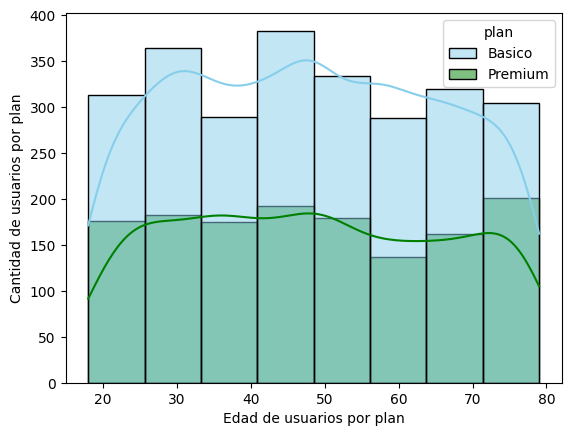

In [159]:
# Histograma para visualizar la edad (age)
sns.histplot(data= user_profile,x='age',hue='plan',bins=8,palette=['skyblue','green'],kde=True)
plt.xlabel('Edad de usuarios por plan')
plt.ylabel('Cantidad de usuarios por plan')
plt.show()

💡Insights: 
-**Plan básico: Presenta una distribución multimodal, es decir, con más de un pico, los cuales se evidencian en los rangos de edad de 30 y 50 años. Adicionalmente, se observa una caída abrupta en la adquisición de este plan después de los 50 años.

-**Plan premium: También muestra una distribución multimodal, con picos ubicados entre los 50 y 70 años. Si bien hay una leve disminución en la adquisición después de los 50 años, esta caída se vuelve más pronunciada a partir de los 70 años.

-**Comparación general: El plan básico concentra una mayor cantidad de usuarios en comparación con el premium, especialmente entre los 30 y 50 años, lo que evidencia una mayor preferencia por este plan en dicho rango de edad. Sin embargo, a partir de los 50 años se observa una transición hacia el plan premium, indicando una mayor preferencia por este último en edades avanzadas, con un consumo destacado especialmente alrededor de los 70 años. 

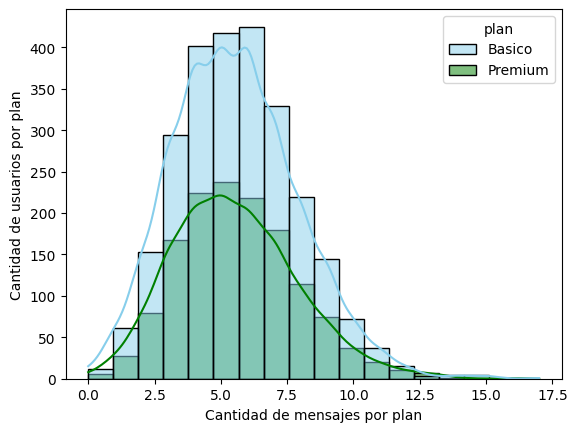

In [160]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data= user_profile,x='cant_mensajes',hue='plan',bins=18,palette=['skyblue','green'],kde=True)
plt.xlabel('Cantidad de mensajes por plan')
plt.ylabel('Cantidad de usuarios por plan')
plt.show()

💡Insights: 
- Ambas distribuciones —tanto del plan básico como del premium— se asemejan a una distribución normal. En el caso de los usuarios premium, se observa un pico claro de 5 mensajes de texto, mientras que para los del plan básico el pico se sitúa en un rango de 2.5 a 7.5 mensajes.

Asimismo, el comportamiento en el envío de mensajes es similar en ambos planes; las diferencias observadas en el volumen total se deben a la cantidad de usuarios, siendo mayor la participación del plan básico. Esto se refleja en la proporción de cada segmento: el plan básico representa el 64.9%, mientras que el premium concentra el 35.1%.

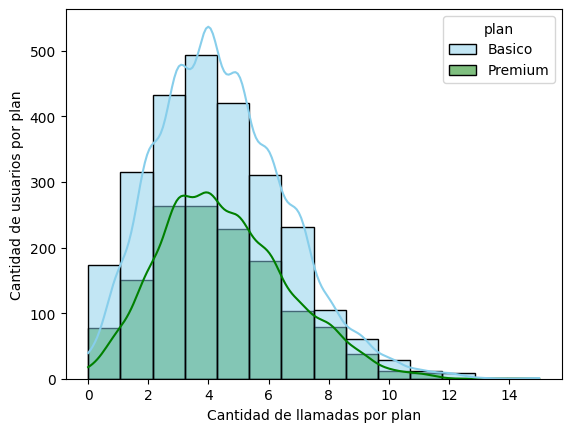

In [161]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data= user_profile,x='cant_llamadas',hue='plan',bins=14,palette=['skyblue','green'],kde=True)
plt.xlabel('Cantidad de llamadas por plan')
plt.ylabel('Cantidad de usuarios por plan')
plt.show()

💡Insights: 
- La distribución de los datos presenta un ligero sesgo hacia la derecha en ambos tipos de plan, debido a la presencia de usuarios que realizan hasta 15 llamadas, lo cual eleva el promedio (situado en 4.48 llamadas). Asimismo, se observa una alta concentración de usuarios que realizan 4 llamadas.

Por otro lado, el comportamiento en la cantidad de llamadas es similar independientemente del plan utilizado; las variaciones aparentes en el volumen total se explican por la proporción de usuarios de cada categoría, donde el plan básico representa el 64.9% y el plan premium el 35.1%. 

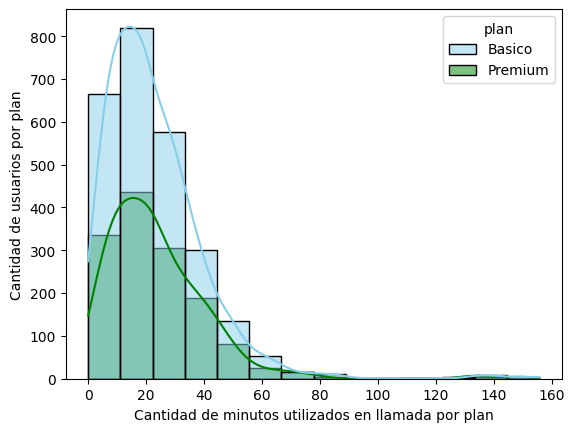

In [162]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data= user_profile,x='cant_minutos_llamada',hue='plan',bins=14,palette=['skyblue','green'],kde=True)
plt.xlabel('Cantidad de minutos utilizados en llamada por plan')
plt.ylabel('Cantidad de usuarios por plan')
plt.show()


💡Insights: 
- La distribución presenta un sesgo hacia la derecha en ambos tipos de plan (premium y básico), impulsada por valores atípicos de usuarios que alcanzan los 150 minutos de llamadas, lo que afecta directamente a la media. Asimismo, en ambos planes se observa un pico claro de 20 minutos utilizados. A partir de los 80 minutos de llamada, se concentra una mayor cantidad de usuarios en el plan premium.

Adicionalmente, el comportamiento en cuanto a la cantidad de llamadas de los usuarios es similar, independientemente del plan que utilicen; las diferencias aparentes se deben a la proporción de usuarios de cada categoría: el plan básico representa el 64.9%, mientras que el plan premium concentra el 35.1%. 


### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

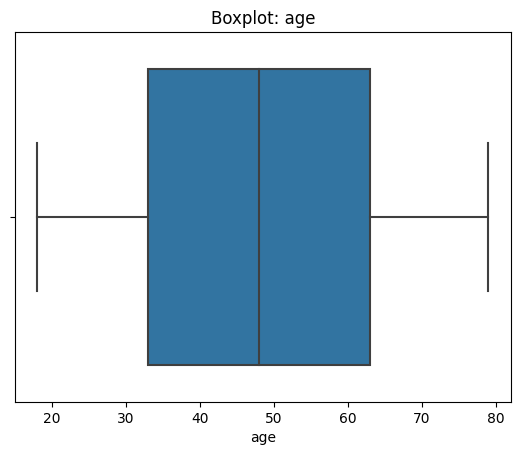

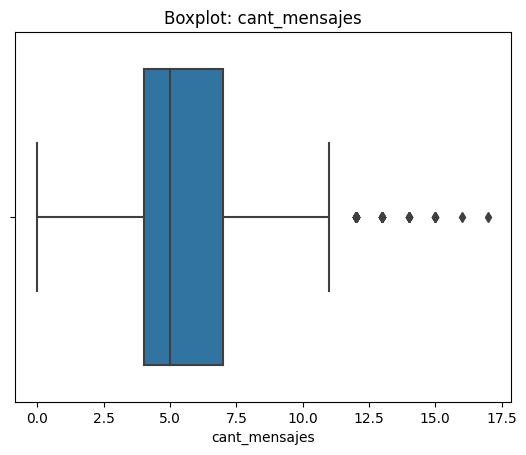

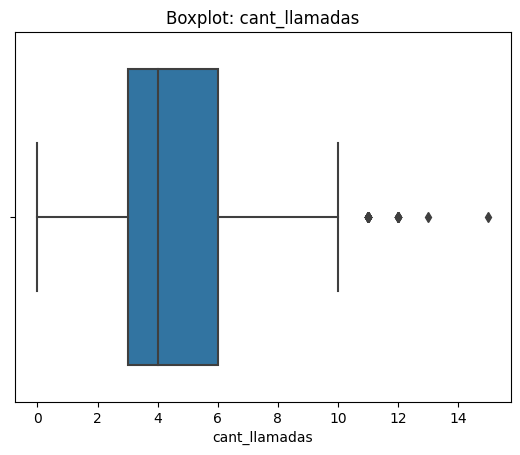

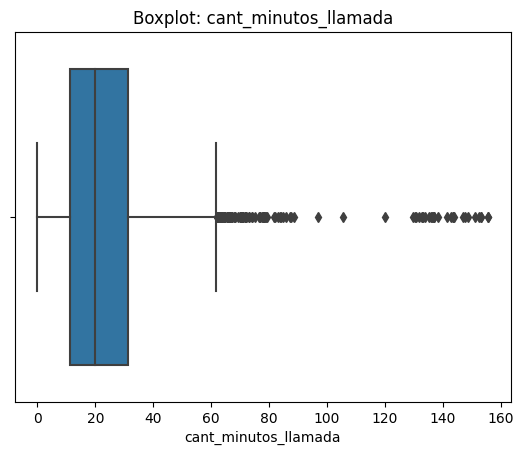

In [163]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data=user_profile, x=col)
    plt.title(f'Boxplot: {col}')
    plt.show()
    

💡Insights: 
- Age: No presenta outliers, los valores se encuentran dentro del rango
- cant_mensajes: Presenta 6 outliers
- cant_llamadas: Presenta 4 outliers
- cant_minutos_llamada: Presenta varios outliers

In [164]:
# Calcular límites con el método IQR
columnas_limites = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1=user_profile[col].quantile(0.25)
    Q3=user_profile[col].quantile(0.75)
    IQR=Q3-Q1
    extremo_superior= Q3+ (1.5*IQR)
    print(f'Extremo superior {col}:',extremo_superior)
    



Extremo superior age: 108.0
Extremo superior cant_mensajes: 11.5
Extremo superior cant_llamadas: 10.5
Extremo superior cant_minutos_llamada: 61.8575


In [165]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: Se mantienen estos outliers, porque es posible que hayan usuarios que tengan el comportamiento de mandar varios mensajes de texto que se salen del limite superior
- cant_llamadas: Se mantienen estos outliers, porque es posible que hayan usuarios que tengan el comportamiento de realizar varias llamadas que se salen del limite superior
- cant_minutos_llamada: Se mantienen estos outliers, porque pueden existir usuarios que se utilicen una mayor cantidad de minutos en una llamada a diferencia del promedio.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [211]:
# Crear columna grupo_uso
def classify_segment(segmentado):
    llamadas= segmentado['cant_llamadas']
    mensajes= segmentado['cant_mensajes']
    #Segmentación 
    if llamadas < 5 and mensajes < 5:
        return "Bajo uso"
    elif llamadas < 10 and mensajes < 10:
        return "Uso medio"
    elif llamadas >= 10 or mensajes >= 10:
        return "Alto uso"
## Creación de fila con la función con condicionales
user_profile['grupo_uso'] = user_profile.apply(classify_segment , axis=1)
user_profile['grupo_uso'].value_counts(normalize=True)

Uso medio    0.735934
Bajo uso     0.194549
Alto uso     0.069517
Name: grupo_uso, dtype: float64

In [179]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto mayor
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto mayor


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [210]:
# Crear columna grupo_edad
def age_segment(segmentado):
    edad=segmentado['age']
    #Segmentación por edades
    if edad < 30:
        return "Joven"
    elif edad < 60:
        return "Adulto"
    elif edad >= 60:
        return "Adulto mayor"
    #Crear columna de edad
user_profile['grupo_edad'] = user_profile.apply(age_segment , axis=1)


Adulto          0.5045
Adulto mayor    0.3055
Joven           0.1900
Name: grupo_edad, dtype: float64

In [185]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto mayor
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

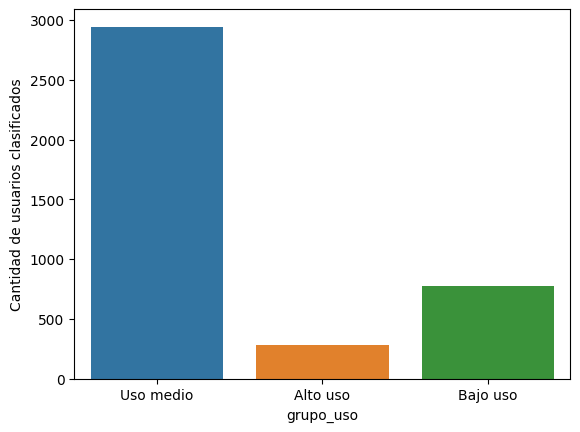

In [188]:
# Visualización de los segmentos por uso

sns.countplot(data= user_profile, x='grupo_uso')
plt.ylabel("Cantidad de usuarios clasificados")
plt.show()


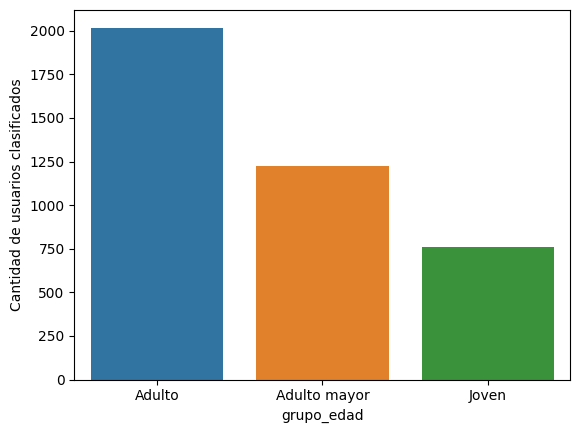

In [209]:
# Visualización de los segmentos por edad
sns.countplot(data= user_profile, x='grupo_edad')
plt.ylabel("Cantidad de usuarios clasificados")
plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Se encontro en la columna de city el sentinel de ?, siendo estas de 65 filas, es decir representaron el 1.6% de los datos.Tambien en age se encontro otro sentinel con el valor de -999 el cuál representon un 1.4% de los datos
- Se econtraron valores nulos en las columnas de duration y lenght del dataset de usage. También se observaron que estos nulos son de tipo MAR.


🔍 **Segmentos por Edad**
- A partir de los 50 años se observa una transición hacia el plan premium, indicando una mayor preferencia por este último en edades avanzadas, con un consumo destacado especialmente alrededor de los 70 años. 
-Se observa una mayor cantidad de usuarios adultos registrados, con un total de 2.000 personas, frente a 1.250 adultos mayores y 750 jóvenes. Esto significa que el número de usuarios adultos es 1,6 veces superior al de adultos mayores y 2,7 veces superior al de jóvenes. 


📊 **Segmentos por Nivel de Uso**
- La segmentación de los usuarios según su nivel de uso de telefonía se concentra principalmente en la categoría de uso medio, que representa el 73,6 % del total. Por su parte, los usuarios de bajo uso corresponden al 19,5 %, mientras que los de alto uso representan el 7,0 %.


➡️ Esto sugiere que hay una mayor concentración de usuarios adultos y que predomina la categoría de uso medio, lo cual indica una oportunidad de aumentar el nivel de uso en el segmento medio y retener los usuarios de edad adulta que son los mas concentrados.


💡 **Recomendaciones**
- Crear campañas de retención para usuarios que se encuentran en el segmento de uso medio de las campañas, como brindarles minutos sin recargo o mensajes de texto, con el fin de evitar que migren a otros operadores
- crear premiaciones de lealtad de uso a usuarios adultos en los rangos de edad entre 30 y 40 años, que brinden minutos y mensajes extra con el fin de mantener retención en estos en la telefonía.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`